## The sample mean ##

We generate random samples and calculate the mean depending on the sample size

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

First we define a function that computes the running mean of our samples.

In [ ]:

def running_mean(x):
    return np.cumsum(x)/(np.arange(len(x))+1) #cumulative sum of array x.
    # np.arange(len(x)) → creates an array [0, 1, 2, ...] up to len(x)-1.
#     For 3 elements, it’s [0, 1, 2].
# np.arange(len(x)) + 1 → gives [1, 2, 3] (to avoid division by zero).



In [ ]:


x = np.random.randint(0,10,size = (10,))
r_m = running_mean(x)
print('data is', x)
print('running mean is ', r_m)


data is [4 8 6 3 9 2 4 1 4 1]
running mean is  [4.         6.         6.         5.25       6.         5.33333333
 5.14285714 4.625      4.55555556 4.2       ]


Next we generate data following a fixed distribution. We decide to take an exponential distribution with density

$$
f(x;\lambda)=
\begin{cases}
\lambda e^{-\lambda x} \quad &x\geq 0, \\
0 & x<0.
\end{cases}
$$

Here $\lambda>0$ is a parameter of the distribution.

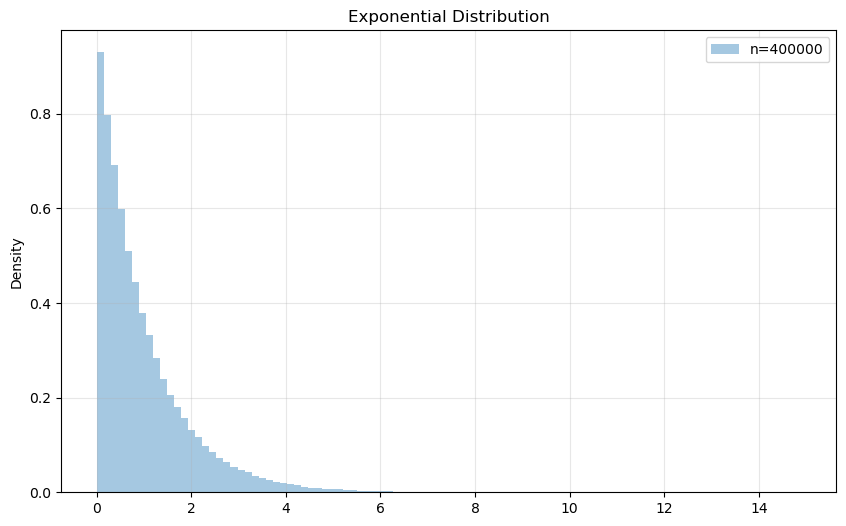

In [ ]:
N = 400000 #sample size
lam = 1
scale = 1/lam
data = np.random.exponential(scale = scale , size = N)

plt.figure(figsize = (10,6))
bins = 100
plt.hist(data,bins= bins, density = True, alpha = 0.4, label = f'n={N}')
plt.title('Exponential Distribution')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

Now we compute the running mean, that is the mean over the first sample, the first two samples, ...

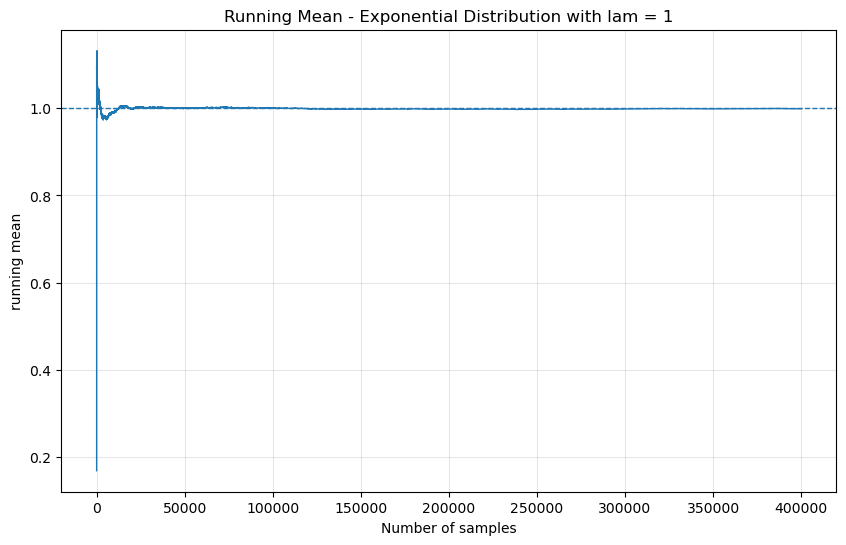

In [ ]:
rm = running_mean(data)

true_mean = 1

plt.figure(figsize = (10,6))
plt.plot(rm, linewidth = 1)
plt.axhline(true_mean, linestyle = '--', linewidth = 1)
plt.title('Running Mean - Exponential Distribution with lam = 1')
plt.xlabel('Number of samples')
plt.ylabel('running mean')
plt.grid(alpha = 0.3)
plt.show()

## The Law of Large Numbers ##
The fact, that the sample mean converges to the expectation value of the underlying distribution is called **The Law of Large Numbers**. It gives a justification for loss-functions for almost all modern machine learning algorithms.

Next we will use a real world dataset called the California Housing dataset, which is included in `scikit-learn`.

In [ ]:
import pandas as pd
from scipy.stats import norm

df = pd.read_csv(r'cal_housing\CaliforniaHousing\cal_housing.data', header = None, sep = ',')
df.columns = ['Longitude', 'Latitude', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup','MedInc','MedHouseVal']

We choose the feature **HouseAge** for our experiment.

20640


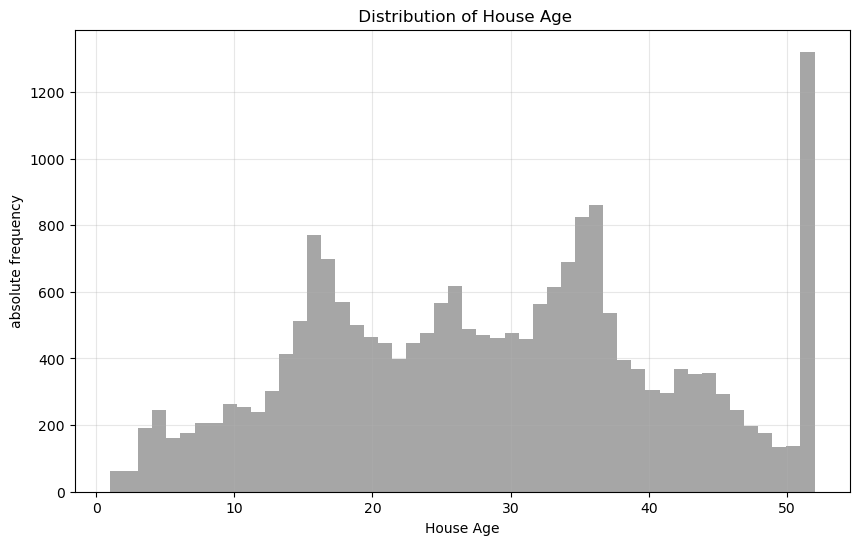

In [ ]:
feature = 'HouseAge'
data_real = df[feature].values
print(len(data_real))

plt.figure(figsize = (10,6))
plt.hist(data_real, bins = 50, alpha = 0.7, color = 'gray', density = False)
plt.title(' Distribution of House Age')
plt.xlabel('House Age')
plt.ylabel('absolute frequency')
plt.grid(alpha = 0.3)
plt.show()

No we randomly sample $n=500$ examples from this data and compute the mean house age. We do this for $trials = 10000$ times.

In [ ]:
n = 500 #number of samples in each trial
trials = 10000

samples = np.random.choice(data_real,size = (trials, n), replace = True)

sample_means = np.mean(samples, axis = 1)
print(sample_means)


[28.472 29.502 28.27  ... 29.392 28.72  28.19 ]


Lets look at a visualization of the distribution of sample means

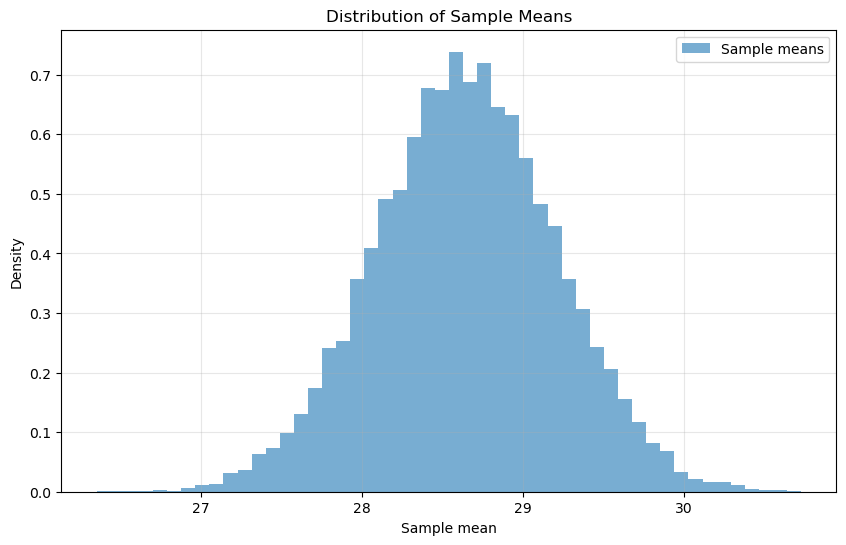

In [ ]:
plt.figure(figsize = (10,6))
plt.hist(sample_means, bins = 50, density = True, alpha = 0.6, label= 'Sample means')
plt.title('Distribution of Sample Means')
plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

If we now normalize the sample means we see that they converge to a standard normal distribution

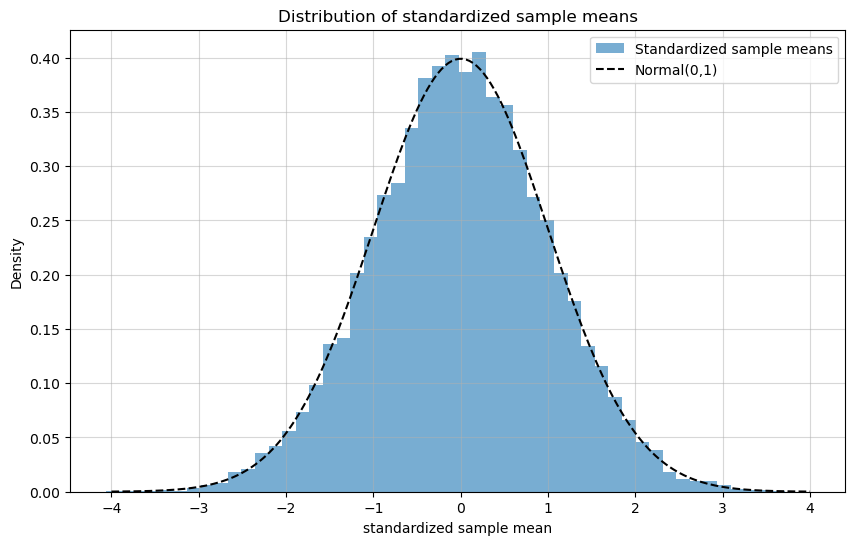

In [ ]:

mu = np.mean(data_real)
sigma = np.std(data_real)

Z = (sample_means-mu)/(sigma/np.sqrt(n))
x = np.linspace(-4,4,200)

plt.figure(figsize = (10,6))
plt.hist(Z, bins = 50, density = True, alpha = 0.6, label = 'Standardized sample means')
plt.plot(x, norm.pdf(x,0,1), 'k--', label = 'Normal(0,1)')
plt.title('Distribution of standardized sample means')
plt.xlabel('standardized sample mean')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha = 0.5)
plt.show()

## Central Limit Theorem ##
This fact, that the samping distribution of the sample mean approaches a normal distribution as the sample size increase, regardless of the populations distribution is called the **Central Limit Theorem**.